In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
estaciones = pd.read_fwf("estaciones_smn.txt", encoding="latin-1", skiprows=[1])
estaciones.head()

,NOMBRE,PROVINCIA,LATITUD,LONGITUD,ALTURA,NRO,NroOACI
0,BASE BELGRANO II,ANTARTIDA,-77 52,-34 37,256.0,89034.0,SAYB
1,BASE CARLINI (EX JUBANY),ANTARTIDA,-62 14,-58 39,11.0,89053.0,SAYJ
2,BASE ESPERANZA,ANTARTIDA,-63 23,-56 59,24.0,88963.0,SAYE
3,BASE MARAMBIO,ANTARTIDA,-64 14,-56 37,198.0,89055.0,SAWB
4,BASE ORCADAS,ANTARTIDA,-60 44,-44 44,12.0,88968.0,SAYO


In [6]:
estaciones.shape

(120, 7)

In [7]:
estaciones["PROVINCIA"].unique()

<StringArray>
[      'ANTARTIDA',    'BUENOS AIRES', 'CAPITAL FEDERAL',       'CATAMARCA',
           'CHACO',               nan,          'CHUBUT',         'CORDOBA',
      'CORRIENTES',      'ENTRE RIOS',         'FORMOSA',           'JUJUY',
        'LA PAMPA',        'LA RIOJA',         'MENDOZA',        'MISIONES',
         'NEUQUEN',       'RIO NEGRO',           'SALTA',        'SAN JUAN',
        'SAN LUIS',      'SANTA CRUZ',        'SANTA FE', 'SANTIAGO DEL ES',
 'TIERRA DEL FUEG',         'TUCUMAN']
Length: 26, dtype: str

In [8]:
estadisticas = pd.read_csv("estadisticas.txt", sep="\t", encoding="latin-1", skiprows=5)
estadisticas.head()

,Estación,Valor Medio de,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
0,LA QUIACA OBS.,Temperatura (°C),12.8,12.5,12.4,10.9,6.9,4.4,4.1,6.7,9.3,11.7,12.8,13.2
1,LA QUIACA OBS.,Temperatura máxima (°C),20.1,19.9,19.9,19.7,17.3,15.6,15.4,17.4,19.2,21.1,21.7,21.3
2,LA QUIACA OBS.,Temperatura mínima (°C),7.4,7.0,6.3,2.8,-3.0,-6.2,-6.8,-4.2,-1.1,2.8,5.2,6.9
3,LA QUIACA OBS.,Humedad relativa (%),65.3,64.1,62.4,48.2,34.6,31.1,30.1,31.7,34.4,45.3,52.3,59.2
4,LA QUIACA OBS.,Velocidad del Viento (km/h),6.9,7.1,6.5,6.4,6.0,4.9,6.6,6.6,8.6,8.7,8.8,8.3


In [ ]:
estadisticas.dtypes

Estación          str
Valor Medio de    str
Ene               str
Feb               str
Mar               str
Abr               str
May               str
Jun               str
Jul               str
Ago               str
Sep               str
Oct               str
Nov               str
Dic               str
dtype: object

In [13]:
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

for mes in meses:
    estadisticas[mes] = pd.to_numeric(estadisticas[mes], errors="coerce")

estadisticas.dtypes

Estación              str
Valor Medio de        str
Ene               float64
Feb               float64
Mar               float64
Abr               float64
May               float64
Jun               float64
Jul               float64
Ago               float64
Sep               float64
Oct               float64
Nov               float64
Dic               float64
dtype: object

In [14]:
estadisticas["promedio_anual"] = estadisticas[meses].mean(axis=1)
estadisticas.head()

,Estación,Valor Medio de,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic,promedio_anual
0,LA QUIACA OBS.,Temperatura (°C),12.8,12.5,12.4,10.9,6.9,4.4,4.1,6.7,9.3,11.7,12.8,13.2,9.808333
1,LA QUIACA OBS.,Temperatura máxima (°C),20.1,19.9,19.9,19.7,17.3,15.6,15.4,17.4,19.2,21.1,21.7,21.3,19.050000
2,LA QUIACA OBS.,Temperatura mínima (°C),7.4,7.0,6.3,2.8,-3.0,-6.2,-6.8,-4.2,-1.1,2.8,5.2,6.9,1.425000
3,LA QUIACA OBS.,Humedad relativa (%),65.3,64.1,62.4,48.2,34.6,31.1,30.1,31.7,34.4,45.3,52.3,59.2,46.558333
4,LA QUIACA OBS.,Velocidad del Viento (km/h),6.9,7.1,6.5,6.4,6.0,4.9,6.6,6.6,8.6,8.7,8.8,8.3,7.116667


In [15]:
tabla = estadisticas.pivot(index="Estación", columns="Valor Medio de", values="promedio_anual")
tabla.head()

Valor Medio de,Frecuencia de días con Precipitación superior a 0.1 mm,Humedad relativa (%),Nubosidad total (octavos),Precipitación (mm),Temperatura (°C),Temperatura máxima (°C),Temperatura mínima (°C),Velocidad del Viento (km/h)
Estación,,,,,,,,
AEROPARQUE AERO,7.608333,72.333333,3.616667,90.125000,17.866667,21.425000,14.508333,15.891667
BAHÍA BLANCA AERO,6.758333,65.641667,3.708333,54.266667,15.291667,22.216667,9.133333,NaN
BARILOCHE AERO,8.841667,66.316667,4.025000,67.641667,8.325000,14.725000,2.366667,19.866667
BASE BELGRANO II,NaN,NaN,4.650000,NaN,-13.341667,-9.908333,-17.433333,NaN
BASE ESPERANZA,NaN,NaN,5.625000,NaN,-4.625000,-0.900000,-8.116667,26.250000


Ahora necesito hacer un merge para poder filtrar por región

In [ ]:
tabla = tabla.reset_index() # Estacion esta consumida como indice en vez de columna, con esto se lo indicamos
tabla.columns.to_list() # me lista todos los nombres de columna exactos asi confirmo la escritura antes de usarlos

['Estación',
 'Frecuencia de días con Precipitación superior a 0.1 mm',
 'Humedad relativa (%)',
 'Nubosidad total (octavos)',
 'Precipitación (mm)',
 'Temperatura (°C)',
 'Temperatura máxima (°C)',
 'Temperatura mínima (°C)',
 'Velocidad del Viento (km/h)']

Ahora uno las dos tablas (es como hacer un JOIN en la base de datos)

In [17]:
df = estaciones.merge(tabla, left_on="NOMBRE", right_on="Estación", how="inner")
df.head()

,NOMBRE,PROVINCIA,LATITUD,LONGITUD,ALTURA,NRO,NroOACI,Estación,Frecuencia de días con Precipitación superior a 0.1 mm,Humedad relativa (%),Nubosidad total (octavos),Precipitación (mm),Temperatura (°C),Temperatura máxima (°C),Temperatura mínima (°C),Velocidad del Viento (km/h)
0,BASE BELGRANO II,ANTARTIDA,-77 52,-34 37,256.0,89034.0,SAYB,BASE BELGRANO II,NaN,NaN,4.650000,NaN,-13.341667,-9.908333,-17.433333,NaN
1,BASE ESPERANZA,ANTARTIDA,-63 23,-56 59,24.0,88963.0,SAYE,BASE ESPERANZA,NaN,NaN,5.625000,NaN,-4.625000,-0.900000,-8.116667,26.250000
2,BASE MARAMBIO,ANTARTIDA,-64 14,-56 37,198.0,89055.0,SAWB,BASE MARAMBIO,NaN,NaN,5.650000,NaN,-8.125000,-4.508333,-11.375000,30.100000
3,BASE ORCADAS,ANTARTIDA,-60 44,-44 44,12.0,88968.0,SAYO,BASE ORCADAS,NaN,NaN,6.933333,NaN,-3.041667,-0.183333,-5.941667,24.000000
4,DOLORES AERO,BUENOS AIRES,-36 19,-57 43,9.0,87648.0,SAZD,DOLORES AERO,8.054545,79.183333,3.800000,84.354545,14.925000,21.183333,14.000000,9.608333


In [18]:
df.shape

(50, 16)

In [19]:
pampeana = ["BUENOS AIRES", "CORDOBA", "SANTA FE", "ENTRE RIOS", "LA PAMPA", "CAPITAL FEDERAL"]
df_pampeana = df[df["PROVINCIA"].isin(pampeana)]
df_pampeana

,NOMBRE,PROVINCIA,LATITUD,LONGITUD,ALTURA,NRO,NroOACI,Estación,Frecuencia de días con Precipitación superior a 0.1 mm,Humedad relativa (%),Nubosidad total (octavos),Precipitación (mm),Temperatura (°C),Temperatura máxima (°C),Temperatura mínima (°C),Velocidad del Viento (km/h)
4,DOLORES AERO,BUENOS AIRES,-36 19,-57 43,9.0,87648.0,SAZD,DOLORES AERO,8.054545,79.183333,3.800000,84.354545,14.925000,21.183333,14.000000,9.608333
5,EL PALOMAR AERO,BUENOS AIRES,-34 36,-58 36,12.0,87571.0,SADP,EL PALOMAR AERO,7.225000,73.858333,3.816667,89.958333,16.800000,22.458333,11.333333,10.616667
6,EZEIZA AERO,BUENOS AIRES,-34 49,-58 32,20.0,87576.0,SAEZ,EZEIZA AERO,7.716667,73.825000,4.033333,84.983333,16.725000,22.466667,11.200000,12.316667
7,LA PLATA AERO,BUENOS AIRES,-34 57,-57 53,23.0,87593.0,SADL,LA PLATA AERO,7.275000,79.466667,3.616667,89.041667,15.891667,21.441667,11.225000,12.608333
8,MAR DEL PLATA AERO,BUENOS AIRES,-37 55,-57 34,21.0,87692.0,SAZM,MAR DEL PLATA AERO,8.683333,79.050000,4.158333,77.175000,13.908333,19.583333,8.691667,14.116667
9,NUEVE DE JULIO,BUENOS AIRES,-35 26,-60 52,76.0,87550.0,SAZX,NUEVE DE JULIO,7.833333,71.150000,3.533333,88.358333,16.083333,22.625000,10.383333,9.708333
10,PUNTA INDIO B.A.,BUENOS AIRES,-35 21,-57 17,22.0,87596.0,SAAI,PUNTA INDIO B.A.,6.758333,81.783333,3.950000,85.850000,16.016667,20.900000,11.825000,16.650000
11,TANDIL AERO,BUENOS AIRES,-37 14,-59 13,175.0,87645.0,SAZT,TANDIL AERO,7.125000,75.016667,3.916667,73.216667,13.541667,20.150000,7.475000,13.316667
12,TRES ARROYOS,BUENOS AIRES,-38 21,-60 17,115.0,87688.0,SAZH,TRES ARROYOS,8.891667,69.425000,4.216667,69.650000,14.141667,20.666667,8.875000,13.875000
13,AEROPARQUE AERO,CAPITAL FEDERAL,-34 33,-58 25,6.0,87582.0,SABE,AEROPARQUE AERO,7.608333,72.333333,3.616667,90.125000,17.866667,21.425000,14.508333,15.891667


### Cuantas estaciones hay en la región pampeana ??

In [26]:
df_pampeana.shape # Entre 11 y 20 estaciones

(19, 16)

### ¿Cuál es la altura media de las estaciones en la región?

In [33]:
altura_media = df_pampeana["ALTURA"].mean()
altura_media

np.float64(91.6842105263158)

### Cuál es la temperatura media (temp) de la región?

In [35]:
temp_media = df_pampeana["Temperatura (°C)"].mean()
temp_media

np.float64(16.62719298245614)

### Desvío estándar de la temperatura?

In [36]:
temp_desv = df_pampeana["Temperatura (°C)"].std()
temp_desv

np.float64(1.8393458690852182)

### En qué mes se registra la mayor precipitación media?

In [37]:
prec = estadisticas[estadisticas["Valor Medio de"] == "Precipitación (mm)"]
prec.head()

,Estación,Valor Medio de,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic,promedio_anual
6,LA QUIACA OBS.,Precipitación (mm),97.5,68.4,55.9,8.2,1.0,0.5,0.0,1.4,3.5,16.0,27.3,71.9,29.300000
14,ORÁN AERO,Precipitación (mm),216.6,183.7,184.2,70.9,19.8,6.3,4.5,5.4,16.3,60.0,108.1,170.1,87.158333
22,TARTAGAL AERO,Precipitación (mm),200.2,182.8,187.7,65.3,22.0,6.7,3.6,5.1,15.1,45.0,110.0,176.4,84.991667
30,JUJUY AERO,Precipitación (mm),153.2,152.9,138.9,49.4,11.6,2.8,3.4,3.1,5.4,28.1,61.1,130.4,61.691667
38,SALTA AERO,Precipitación (mm),192.6,154.2,110.6,33.0,8.0,1.5,3.9,3.8,7.6,25.1,62.2,145.6,62.341667


In [40]:
nombres_pampeana = df_pampeana["NOMBRE"]
prec_pampeana = prec[prec["Estación"].isin(nombres_pampeana)]
prec_pampeana

,Estación,Valor Medio de,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic,promedio_anual
142,CERES AERO,Precipitación (mm),132.0,122.4,153.5,95.4,35.4,18.7,15.6,13.0,36.4,83.8,103.2,143.7,79.425000
150,RECONQUISTA AERO,Precipitación (mm),141.4,156.6,168.3,155.6,58.9,49.3,31.2,26.3,53.1,114.0,159.8,136.4,104.241667
182,VILLA DOLORES AERO,Precipitación (mm),121.1,102.2,94.4,42.4,17.6,4.7,13.2,6.1,22.9,35.1,75.1,113.3,54.008333
214,SAUCE VIEJO AERO,Precipitación (mm),95.4,112.0,146.4,116.2,49.4,31.5,23.9,28.4,53.2,110.5,128.9,124.9,85.058333
238,CONCORDIA AERO,Precipitación (mm),133.9,145.7,156.5,163.4,99.7,82.4,52.2,58.7,85.6,136.9,140.8,121.0,114.733333
302,ROSARIO AERO,Precipitación (mm),111.8,120.6,144.8,111.8,59.0,27.7,24.7,32.4,47.4,108.5,112.3,120.6,85.133333
334,GENERAL PICO AERO,Precipitación (mm),111.2,102.7,143.8,70.4,32.8,17.4,22.0,24.9,55.2,87.2,99.8,124.4,74.316667
342,LABOULAYE AERO,Precipitación (mm),120.7,105.7,138.8,83.4,36.0,11.7,17.6,17.2,47.3,91.0,105.0,128.7,75.258333
366,NUEVE DE JULIO,Precipitación (mm),127.9,114.2,144.8,110.3,60.8,38.4,38.3,35.2,61.7,113.0,108.8,106.9,88.358333
382,EL PALOMAR AERO,Precipitación (mm),117.5,115.0,121.9,104.3,78.9,49.7,50.3,54.5,57.2,117.7,106.6,105.9,89.958333


In [41]:
prec_por_mes = prec_pampeana[meses].mean()
prec_por_mes

Ene    111.389474
Feb    111.010526
Mar    124.189474
Abr     95.826316
May     58.647368
Jun     39.436842
Jul     38.563158
Ago     40.578947
Sep     56.355556
Oct     98.721053
Nov    105.968421
Dic    107.531579
dtype: float64

In [42]:
prec_por_mes.idxmax()

'Mar'

### Qué provincia tiene la mayor temperatura media?

In [43]:
temp_por_provincia = df_pampeana.groupby("PROVINCIA")["Temperatura (°C)"].mean()
temp_por_provincia

PROVINCIA
BUENOS AIRES       15.337037
CAPITAL FEDERAL    17.866667
CORDOBA            17.108333
ENTRE RIOS         18.900000
LA PAMPA           15.833333
SANTA FE           18.808333
Name: Temperatura (°C), dtype: float64

### En qué variable(s) aparecen outliers?

Temperatura

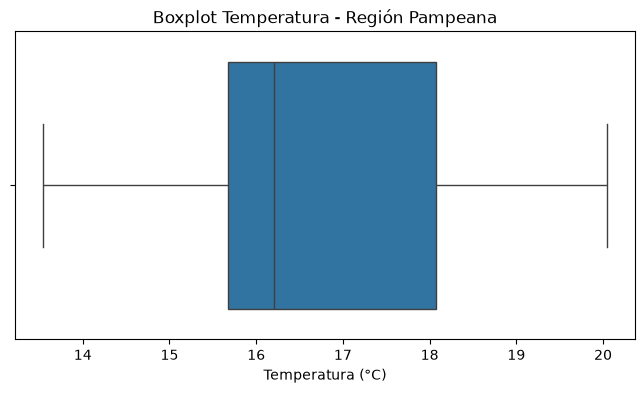

In [44]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_pampeana["Temperatura (°C)"])
plt.title("Boxplot Temperatura - Región Pampeana")
plt.show()

Precipitación (mm)

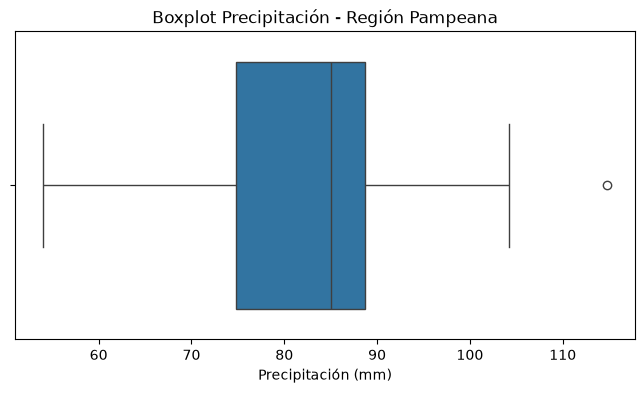

In [46]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_pampeana["Precipitación (mm)"])
plt.title("Boxplot Precipitación - Región Pampeana")
plt.show()

### Coeficiente de correlación de Spearman entre la altura de las estaciones y la temperatura

In [47]:
df_pampeana["ALTURA"].corr(df_pampeana["Temperatura (°C)"], method="spearman")

np.float64(-0.14385964912280702)

### Valor de eta cuadrado para las variables provincia y precipitación

No hay una función que calcule el valor de eta, lo calculo a mano

In [48]:
def eta_cuadrado(df, categorica, numerica):
    media_general = df[numerica].mean()

    ss_entre = 0
    for grupo, datos in df.groupby(categorica):
        ss_entre += len(datos) * (datos[numerica].mean() - media_general) **2

    ss_total = ((df[numerica] - media_general)**2).sum()

    return ss_entre/ ss_total

In [49]:
eta = eta_cuadrado(df_pampeana, "PROVINCIA", "Precipitación (mm)")
eta

np.float64(0.6777702418071974)

#### Elegí una provincia de la región y describí brevemente su clima utilizando al menos tres variables del dataset (temperatura, precipitación, humedad, nubosidad o viento).

In [52]:
prov = df_pampeana[df_pampeana["PROVINCIA"] == "BUENOS AIRES"]
prov[["Temperatura (°C)", "Precipitación (mm)", "Humedad relativa (%)", 
      "Nubosidad total (octavos)", "Velocidad del Viento (km/h)"]].mean()

Temperatura (°C)               15.337037
Precipitación (mm)             82.509764
Humedad relativa (%)           75.862037
Nubosidad total (octavos)       3.893519
Velocidad del Viento (km/h)    12.535185
dtype: float64